In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

In [2]:
path = kagglehub.dataset_download("adityakadiwal/water-potability")
print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'water-potability' dataset.
Dataset path: /kaggle/input/water-potability
['water_potability.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "water_potability.csv"))
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [7]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [8]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [9]:
df["Potability"].value_counts()

,count
Potability,
0,1998
1,1278


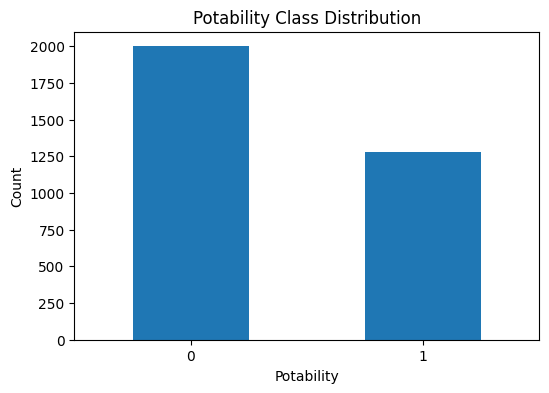

In [10]:
plt.figure(figsize=(6, 4))
df["Potability"].value_counts().plot(kind="bar")
plt.title("Potability Class Distribution")
plt.xlabel("Potability")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

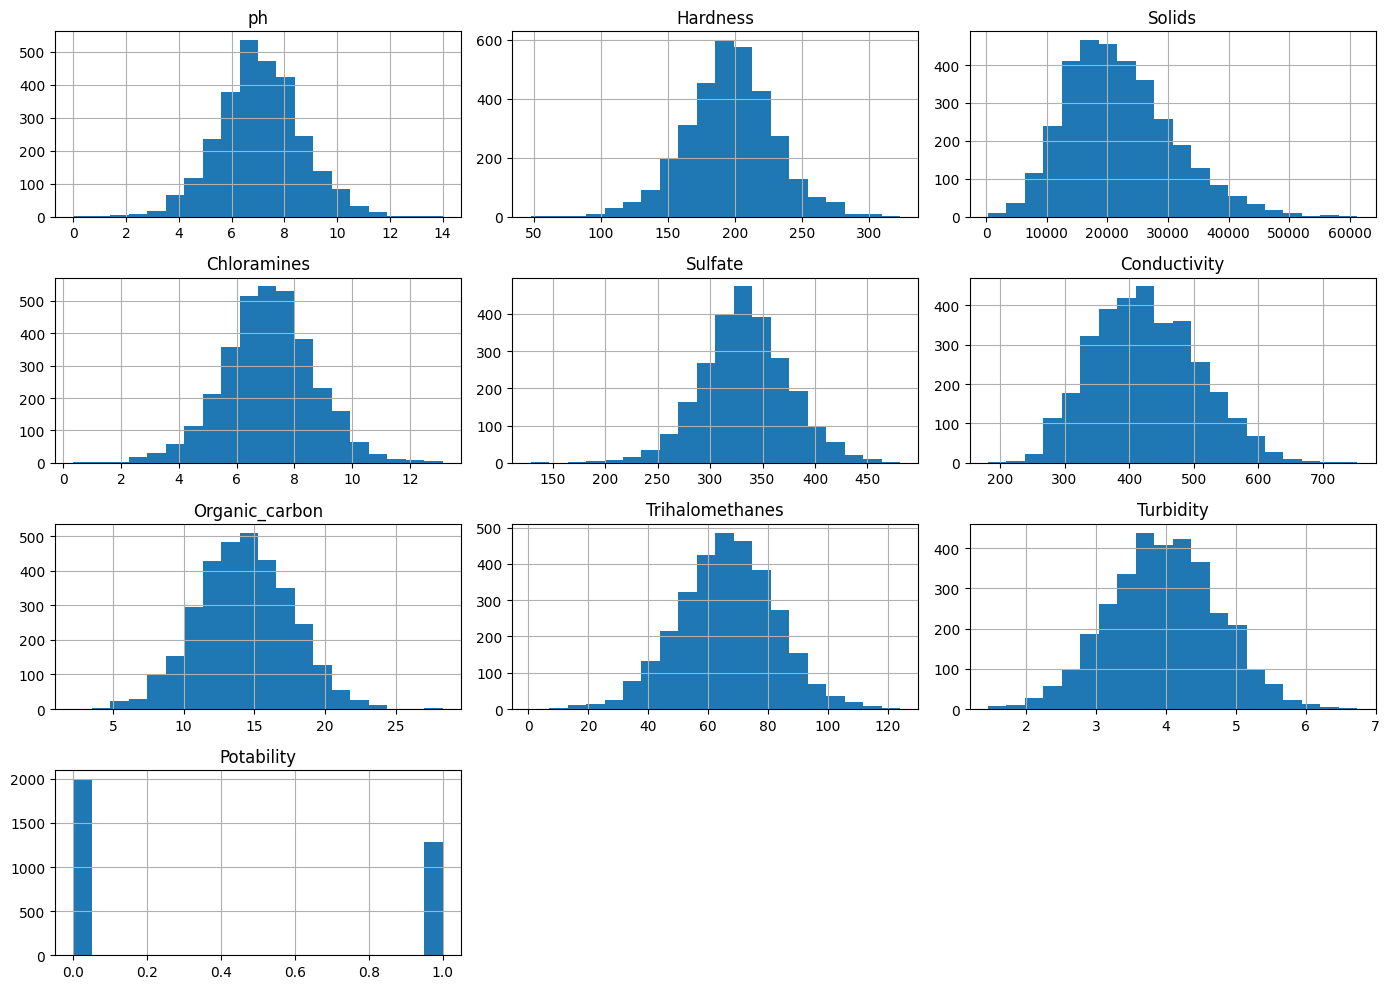

In [11]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

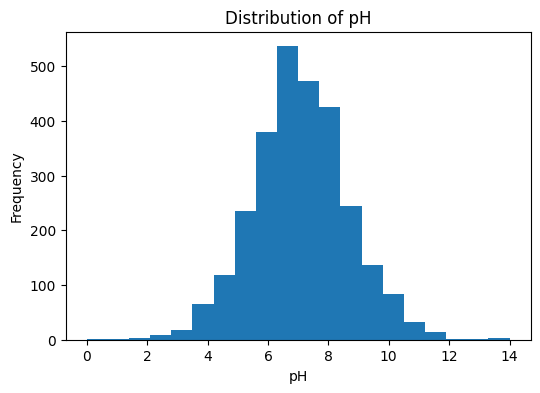

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(df["ph"].dropna(), bins=20)
plt.title("Distribution of pH")
plt.xlabel("pH")
plt.ylabel("Frequency")
plt.show()

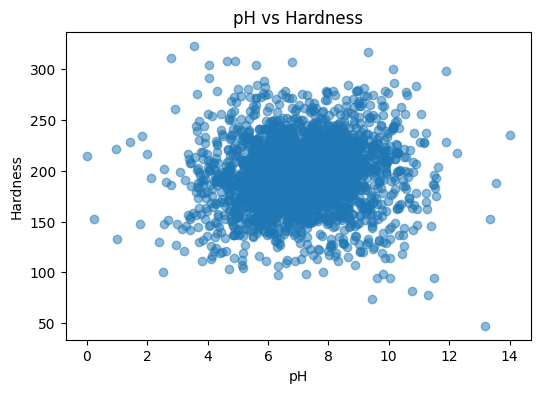

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(df["ph"], df["Hardness"], alpha=0.5)
plt.title("pH vs Hardness")
plt.xlabel("pH")
plt.ylabel("Hardness")
plt.show()

In [14]:
df["ph"] = df["ph"].fillna(df["ph"].median())
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].median())

df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


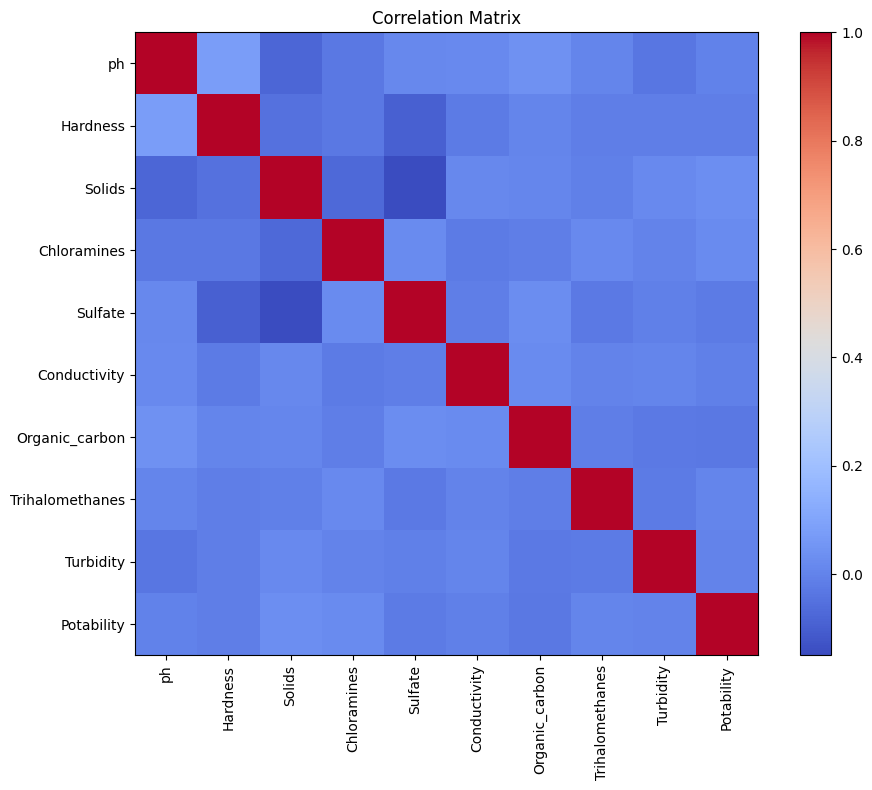

In [15]:
corr = df.corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
X = df.drop("Potability", axis=1)
y = df["Potability"]
print(X.shape)
print(y.shape)

(3276, 9)
(3276,)


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2620, 9)
Testing data: (656, 9)


In [18]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Potability
0    1598
1    1022
Name: count, dtype: int64


In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train.value_counts())

After SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64


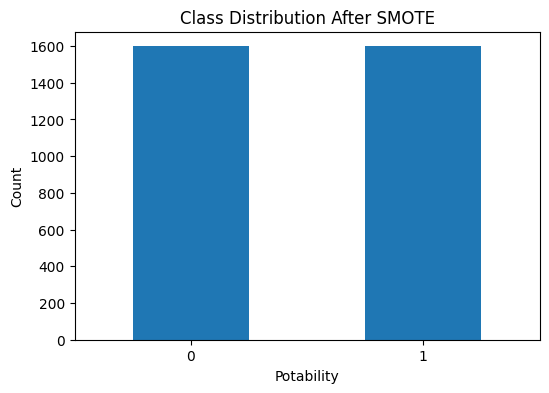

In [20]:
plt.figure(figsize=(6, 4))
y_train.value_counts().plot(kind="bar")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Potability")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6509146341463414


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.50      0.53       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.63       656
weighted avg       0.65      0.65      0.65       656



In [25]:
confusion_matrix(y_test, y_pred)

array([[299, 101],
       [128, 128]])

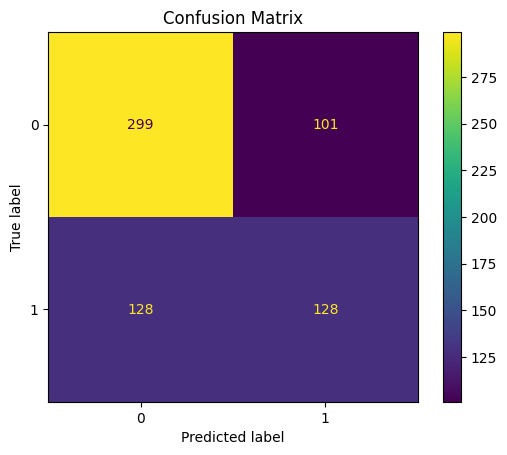

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [27]:
importance = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)
importance

,0
ph,0.136587
Sulfate,0.121600
Solids,0.120627
Hardness,0.114865
Chloramines,0.113576
Turbidity,0.099440
Conductivity,0.098856
Organic_carbon,0.098655
Trihalomethanes,0.095794


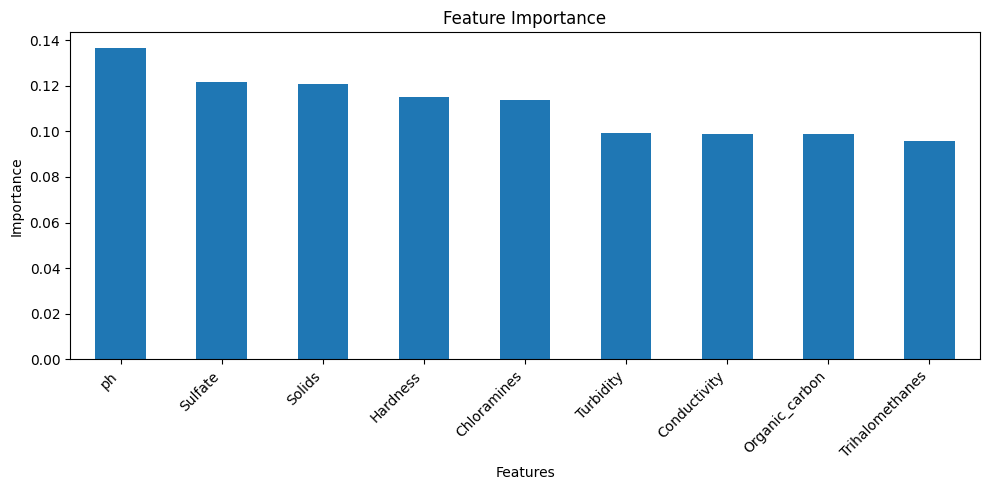

In [28]:
plt.figure(figsize=(10, 5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()